## Importando as Bibliotecas

In [10]:
# Importacao das bibliotecas necessarias
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

## Definição do Construtor da Classe

In [11]:
class MLPClassifier:
    def __init__(self, hidden_layers=[64, 32], activation='relu', learning_rate=0.01,
                 epochs=100, patience=5, batch_size=32, optimizer='adam', regularization=None,
                 dropout_p=0.1, lambda_12=0.001, random_state=None):
        """
        Inicializa o classificador MLP para problemas multiclasse.

        Parâmetros:
        hidden_layers: lista com número de neurônios em cada camada oculta
        activation: função de ativação ('relu' ou 'tanh')
        learning_rate: taxa de aprendizado
        epochs: número máximo de épocas
        patience: paciência para early stopping
        batch_size: tamanho do batch para treinamento
        optimizer: 'sgd' ou 'adam', o otimizador a ser usado
        regularization: 'dropout', 'l2' ou None, tipo de regularização a ser aplicado
        dropout_p: probabilidade de dropout (para regularização dropout)
        lambda_12: fator de regularização L2 (para penalização L2)
        random_state: semente para reprodutibilidade
        """
        # Parametros da arquitetura da rede
        self.hidden_layers = hidden_layers
        self.activation = activation.lower()
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.patience = patience
        self.batch_size = batch_size
        self.optimizer = optimizer.lower()
        self.regularization = regularization
        self.dropout_p = dropout_p
        self.lambda_12 = lambda_12
        self.random_state = random_state

        # Inicializa historicos e modelo como vazios
        self.model = None
        self.loss_history = {'train': [], 'val': []}
        self.accuracy_history = {'train': [], 'val': []}
        self.classes_ = None

        # Define o dispositivo (GPU se disponivel, senao CPU)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        print(f"Usando dispositivo: {self.device}")
        print(f"Cuda habilitado? {torch.cuda.is_available()}") # Deve retornar True
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Define semente aleatoria para reprodutibilidade
        if random_state is not None:
            torch.manual_seed(random_state)
            np.random.seed(random_state)

## Construindo as Camadas do Modelo

In [12]:
def _build_model(self, input_dim, output_dim):
        # Constrói a arquitetura do modelo PyTorch com regularização, se necessário.
        layers = []  # Lista que armazenara as camadas sequenciais
        prev_dim = input_dim  # Dimensao de entrada para a primeira camada

        # Percorre cada camada oculta definida em self.hidden_layers
        for dim in self.hidden_layers:
            # Adiciona camada linear (fully connected)
            layers.append(nn.Linear(prev_dim, dim))
            # Adiciona funcao de ativacao conforme escolha do usuario
            if self.activation == 'relu':
                layers.append(nn.ReLU())
            elif self.activation == 'tanh':
                layers.append(nn.Tanh())

            # Aplica dropout, se a regularização for 'dropout'
            if self.regularization == 'dropout':
                layers.append(nn.Dropout(p=self.dropout_p))

            prev_dim = dim  # Atualiza para a proxima camada

        # Camada de saida (sem ativacao quando usando CrossEntropy Loss)
        layers.append(nn.Linear(prev_dim, output_dim))

        # Retorna o modelo como Sequential e move para o dispositivo (GPU/CPU)
        return nn.Sequential(*layers).to(self.device)

# Vincula a funcao _build_model como metodo da classe MLPClassifier
MLPClassifier._build_model = _build_model

## Implementação do Método Fit (Treinamento)

In [13]:
def fit(self, X_train, y_train, X_val=None, y_val=None):
        # Treina o modelo MLP para classificacao multiclasse.

        start = time.time()  # Marca o inicio do treinamento

        # Converte os dados de entrada para tensores PyTorch e move para o dispositivo
        X_train_tensor = torch.FloatTensor(X_train).to(self.device)
        y_train_tensor = torch.LongTensor(y_train).to(self.device)

        # Se dados de validacao forem fornecidos, converte tambem
        if X_val is not None and y_val is not None:
            X_val_tensor = torch.FloatTensor(X_val).to(self.device)
            y_val_tensor = torch.LongTensor(y_val).to(self.device)
            validation_data = (X_val_tensor, y_val_tensor)
        else:
            validation_data = None

        # Determina dimensoes de entrada e saida com base nos dados
        input_dim = X_train.shape[1]
        self.classes_ = torch.unique(y_train_tensor)
        output_dim = len(self.classes_)

        # Constroi o modelo com a arquitetura definida
        self.model = self._build_model(input_dim, output_dim)

        # Mostra informacoes da GPU se disponivel
        if torch.cuda.is_available():
            id = torch.cuda.current_device()
            print(f"GPU em uso: {torch.cuda.get_device_name(id)}")
        else:
            print("GPU nao disponivel, usando CPU.")

        # Define a funcao de perda: CrossEntropy para multiclasse, BCE para binario
        criterion = nn.CrossEntropyLoss() if output_dim > 1 else nn.BCEWithLogitsLoss()

        # Seleciona o otimizador com base na escolha do usuario
        if self.optimizer == 'sgd':
            optimizer = optim.SGD(self.model.parameters(), lr=self.learning_rate)
        elif self.optimizer == 'adam':
            # Aplica regularizacao L2, se for solicitada
            if self.regularization == 'l2':
                optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate, weight_decay=self.lambda_12)
            else:
                optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        else:
            raise ValueError("O otimizador deve ser 'sgd' ou 'adam'.")

        # Variaveis para early stopping
        best_loss = np.inf
        patience_counter = 0
        best_weights = None

        # Loop principal de treinamento (epocas)
        for epoch in range(self.epochs):
            self.model.train().to(self.device)  # Ativa modo de treinamento
            epoch_loss = 0.0
            correct = 0
            total = 0

            # Treinamento em mini-batches
            for i in range(0, len(X_train), self.batch_size):
                batch_X = X_train_tensor[i:i+self.batch_size]
                batch_y = y_train_tensor[i:i+self.batch_size]

                # Passo do gradiente descendente
                optimizer.zero_grad()  # Zera os gradientes
                outputs = self.model(batch_X)  # Forward pass
                loss = criterion(outputs, batch_y)  # Calcula a perda

                loss.backward()  # Backward pass (calcula gradientes)
                optimizer.step()  # Atualiza os pesos

                # Acumula metricas da epoca
                epoch_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == batch_y).sum().item()
                total += batch_y.size(0)

            # Calcula metricas medias de treinamento da epoca
            train_loss = epoch_loss / (len(X_train) / self.batch_size)
            train_acc = correct / total

            # Armazena historico de treinamento
            self.loss_history['train'].append(train_loss)
            self.accuracy_history['train'].append(train_acc)

            # Validacao
            val_loss, val_acc = None, None
            if validation_data is not None:
                self.model.eval()  # Ativa modo de avaliacao
                with torch.no_grad():  # Desativa calculo de gradientes
                    X_val_tensor, y_val_tensor = validation_data
                    outputs = self.model(X_val_tensor)
                    val_loss = criterion(outputs, y_val_tensor).item()
                    _, predicted = torch.max(outputs.data, 1)
                    val_acc = (predicted == y_val_tensor).sum().item() / len(y_val_tensor)

                # Armazena historico de validacao
                self.loss_history['val'].append(val_loss)
                self.accuracy_history['val'].append(val_acc)

                # Early stopping: interrompe se a perda nao melhora
                if val_loss < best_loss:
                    best_loss = val_loss
                    patience_counter = 0
                    best_weights = self.model.state_dict()
                else:
                    patience_counter += 1

                if patience_counter >= self.patience:
                    print(f"Early stopping na epoca {epoch+1}")
                    self.model.load_state_dict(best_weights)
                    break

            # Exibe progresso a cada 10 epocas (e na primeira)
            if (epoch+1) % 10 == 0 or epoch == 0:
                msg = f"Epoca {epoch+1}/{self.epochs} - Treinamento Loss: {train_loss:.4f}, Treinamento Acuracia: {train_acc*100:.2f}%"
                if val_loss is not None:
                    msg += f", Validacao Loss: {val_loss:.4f}, Validacao Acuracia: {val_acc*100:.2f}%"
                print(msg)

        end = time.time()
        tranning_time = end - start
        print(f"Tempo total de treinamento: {tranning_time:.2f} segundos")

# Vincula a funcao fit como metodo da classe MLPClassifier
MLPClassifier.fit = fit

## Implementação do Método Predict

In [14]:
def predict(self, X):
        # Verifica se o modelo ja foi treinado
        if self.model is None:
            raise RuntimeError("O modelo nao foi treinado ainda. Chame fit() primeiro.")

        self.model.eval()  # Ativa modo de avaliacao
        with torch.no_grad():  # Desativa gradientes para economia de memoria
            X_tensor = torch.FloatTensor(X).to(self.device)
            outputs = self.model(X_tensor)
            _, predictions = torch.max(outputs.data, 1)  # Pega a classe com maior probabilidade

        return predictions.cpu().numpy()  # Move para CPU e converte para numpy

# Vincula a funcao predict como metodo da classe MLPClassifier
MLPClassifier.predict = predict

## Implementação do Método Evaluate

In [15]:
def evaluate(self, X, y):
        # Faz as previsoes e calcula a acuracia comparando com os rotulos verdadeiros
        predictions = self.predict(X)
        accuracy = np.mean(predictions == y)
        return accuracy

# Vincula a funcao evaluate como metodo da classe MLPClassifier
MLPClassifier.evaluate = evaluate

## Implementação do Método para Plotar o Gráfico de Treinamento

In [16]:
def plot_training_history(self):
        # Cria uma figura com dois graficos lado a lado
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Grafico da funcao de perda (loss) ao longo das epocas
        ax1.plot(self.loss_history['train'], label='Loss do Treinamento')
        if self.loss_history['val']:
            ax1.plot(self.loss_history['val'], label='Loss da Validacao')
        ax1.set_title('Loss do Treinamento e Validacao')
        ax1.set_xlabel('Epoca')
        ax1.set_ylabel('Loss')
        ax1.legend()

        # Grafico da acuracia ao longo das epocas
        ax2.plot(self.accuracy_history['train'], label='Acuracia de Treinamento')
        if self.accuracy_history['val']:
            ax2.plot(self.accuracy_history['val'], label='Acuracia de Validacao')
        ax2.set_title('Acuracia do Treinamento e Validacao')
        ax2.set_xlabel('Epoca')
        ax2.set_ylabel('Acuracia')
        ax2.legend()

        plt.tight_layout()  # Ajusta o espacamento entre os graficos
        plt.show()

# Vincula a funcao plot_training_history como metodo da classe MLPClassifier
MLPClassifier.plot_training_history = plot_training_history

## Implementação do Método para Plotar a Fronteira de Decisão

In [17]:
def plot_decision_boundary(self, X, y, step=0.02):
        # So e possivel plotar fronteira de decisao para dados 2D
        if X.shape[1] != 2:
            print("A fronteira de decisao so pode ser plotada para dados 2D.")
            return

        # Define os limites do grid com uma margem de 0.1
        x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
        y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

        # Cria um grid de pontos para avaliar o modelo
        xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                             np.arange(y_min, y_max, step))

        grid_points = np.c_[xx.ravel(), yy.ravel()]

        # Faz a previsao para cada ponto do grid
        predictions = self.predict(grid_points).reshape(xx.shape)

        # Plota a fronteira de decisao com contornos coloridos
        plt.contourf(xx, yy, predictions, alpha=0.75)
        # Plota os pontos originais sobre a fronteira
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
        plt.title('Fronteira de Decisao')
        plt.show()

# Vincula a funcao plot_decision_boundary como metodo da classe MLPClassifier
MLPClassifier.plot_decision_boundary = plot_decision_boundary

## Exemplo de Como Usar a Classe

Usando dispositivo: cpu
Cuda habilitado? False
GPU nao disponivel, usando CPU.
Epoca 1/100 - Treinamento Loss: 0.7740, Treinamento Acuracia: 68.57%
Epoca 10/100 - Treinamento Loss: 0.7020, Treinamento Acuracia: 80.00%
Epoca 20/100 - Treinamento Loss: 0.5848, Treinamento Acuracia: 90.00%
Epoca 30/100 - Treinamento Loss: 0.4297, Treinamento Acuracia: 96.43%
Epoca 40/100 - Treinamento Loss: 0.2792, Treinamento Acuracia: 97.86%
Epoca 50/100 - Treinamento Loss: 0.2166, Treinamento Acuracia: 97.86%
Epoca 60/100 - Treinamento Loss: 0.1818, Treinamento Acuracia: 98.57%
Epoca 70/100 - Treinamento Loss: 0.1423, Treinamento Acuracia: 97.86%
Epoca 80/100 - Treinamento Loss: 0.1655, Treinamento Acuracia: 97.86%
Epoca 90/100 - Treinamento Loss: 0.1067, Treinamento Acuracia: 98.57%
Epoca 100/100 - Treinamento Loss: 0.1089, Treinamento Acuracia: 98.57%
Tempo total de treinamento: 0.86 segundos

Acuracia do Teste: 95.00%


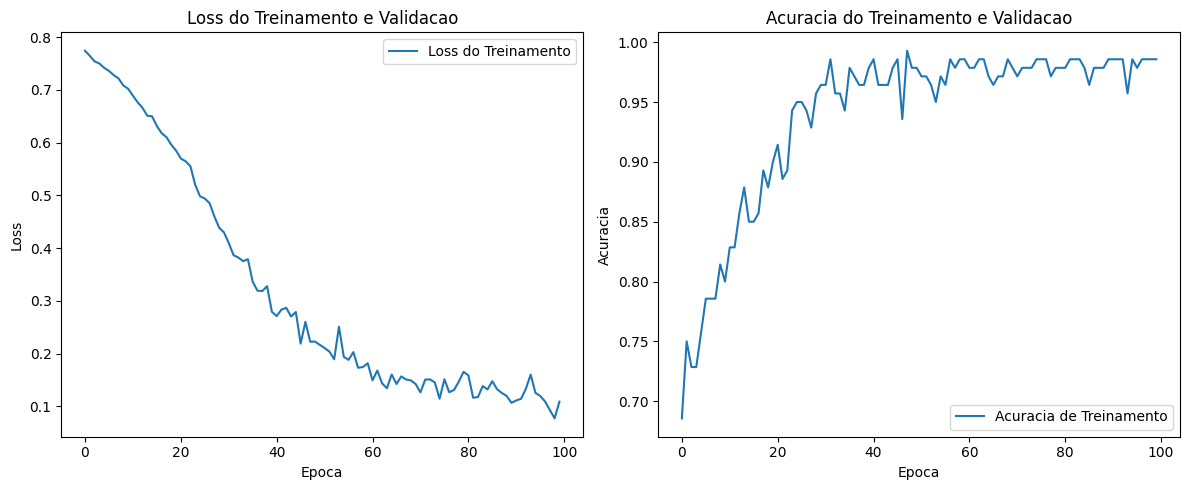

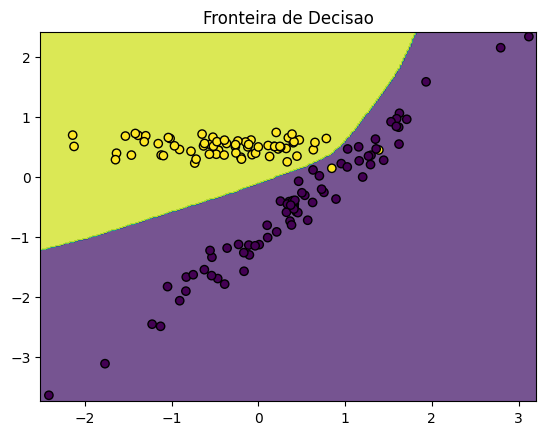

Previsoes para o conjunto de teste: [1 1 1 0 1 0 0 0 0 1 0 0 1 1 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1
 0 1 0 0 0 1 0 1 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0]


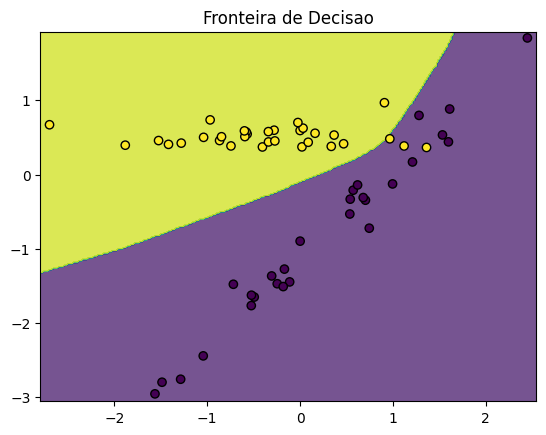

In [18]:
# ============================================================
# Exemplo de uso da classe MLPClassifier
# ============================================================

# --- Carregamento do conjunto de treinamento (dataset1: 2 features) ---
data = np.genfromtxt('train_dataset1.csv', delimiter=',', skip_header=1)
X_train = data[:, :-1]  # Features (todas as colunas exceto a ultima)
y_train = data[:, -1]   # Labels (ultima coluna)
y_train = (y_train + 1) // 2  # Converte rotulos de -1/1 para 0/1

# --- Carregamento do conjunto de teste (dataset1: 2 features) ---
data = np.genfromtxt('test_dataset1.csv', delimiter=',', skip_header=1)
X_test = data[:, :-1]   # Features
y_test = data[:, -1]    # Labels
y_test = (y_test + 1) // 2  # Converte rotulos de -1/1 para 0/1

# --- Criacao e configuracao do classificador ---
mlp = MLPClassifier(optimizer='adam',
                    learning_rate=0.001,
                    hidden_layers=[10, 10],
                    activation='relu',
                    regularization='dropout',
                    dropout_p=0.1)

# --- Treinamento do modelo ---
mlp.fit(X_train, y_train)

# --- Avaliacao no conjunto de teste ---
test_acc = mlp.evaluate(X_test, y_test)
print(f"\nAcuracia do Teste: {test_acc*100:.2f}%")

# --- Visualizacao do historico de treinamento ---
mlp.plot_training_history()

# --- Visualizacao da fronteira de decisao (apenas para dados 2D) ---
mlp.plot_decision_boundary(X_train, y_train)

# --- Previsoes finais no conjunto de teste ---
y_pred = mlp.predict(X_test)
print(f"Previsoes para o conjunto de teste: {y_pred}")

# --- Fronteira de decisao para o conjunto de teste ---
mlp.plot_decision_boundary(X_test, y_test)